In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [2]:
#importing data
df=pd.read_csv(r"C:\Users\naadu\Documents\my_lab_sem2\NY_Housing.csv")

In [3]:
# 1 understanding the data

In [4]:
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [5]:
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [6]:
df.shape

(4801, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [8]:
df.isnull().sum()

BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

In [8]:
#  Q2 initial visualization

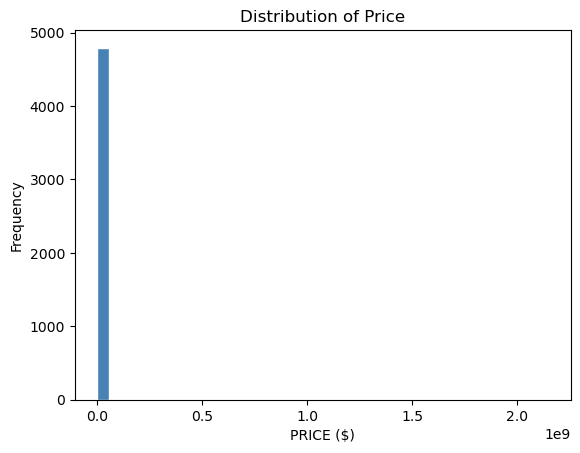

In [9]:
# DISTRIBUTION — Price Histogram
plt.figure()
plt.hist(df['PRICE'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('PRICE ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Price')
plt.show()

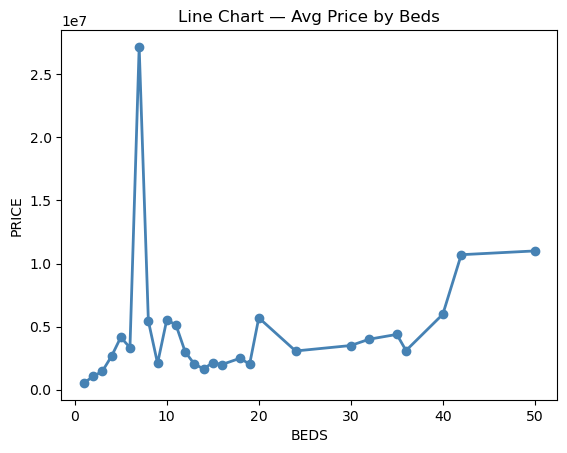

In [10]:
# LINE CHART — Average Price by Beds
avg_price = df.groupby('BEDS')['PRICE'].mean()
plt.figure()
plt.plot(avg_price.index, avg_price.values, marker='o', color='steelblue', linewidth=2)
plt.xlabel('BEDS')
plt.ylabel('PRICE')
plt.title('Line Chart — Avg Price by Beds')
plt.show()

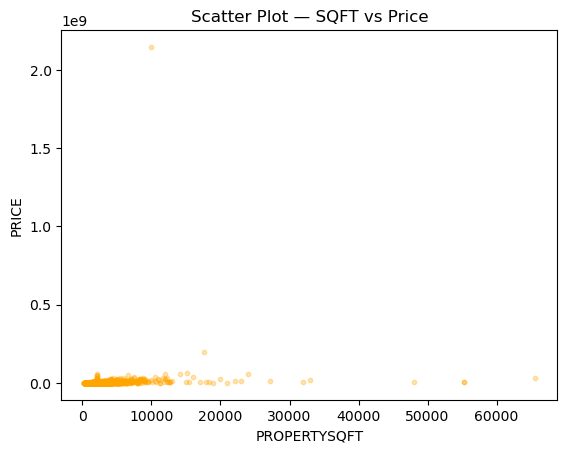

In [11]:
# SCATTER — SQFT vs Price
plt.figure()
plt.scatter(df['PROPERTYSQFT'], df['PRICE'], alpha=0.3, s=10, color='orange')
plt.xlabel('PROPERTYSQFT')
plt.ylabel('PRICE')
plt.title('Scatter Plot — SQFT vs Price')
plt.show()

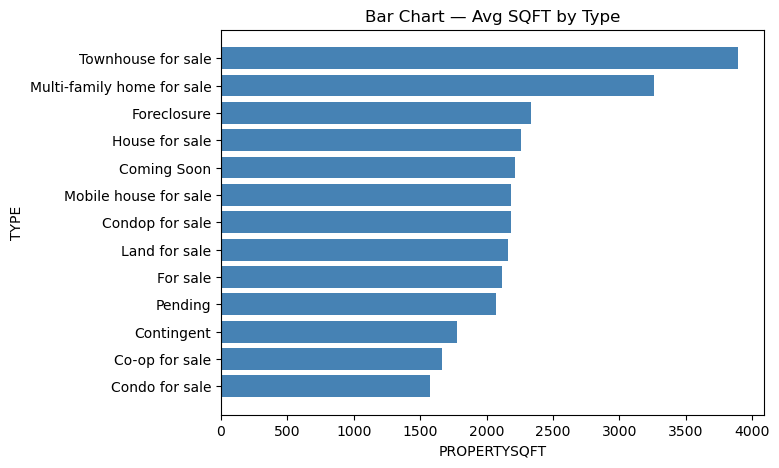

In [12]:
# BAR CHART — Avg SQFT by Property Type
plt.figure(figsize=(7, 5))
avg_sqft = df.groupby('TYPE')['PROPERTYSQFT'].mean().sort_values()
plt.barh(avg_sqft.index, avg_sqft.values, color='steelblue')
plt.xlabel('PROPERTYSQFT')
plt.ylabel('TYPE')
plt.title('Bar Chart — Avg SQFT by Type')
plt.show()

In [13]:
# Q3 Data Preparation Exercise

In [13]:
# looking for duplicates
print(df.duplicated().sum())

214


In [14]:
# dropping duplicates
df = df.drop_duplicates()
print(df.shape)  

(4587, 17)


In [15]:
# Cap outliers using the IQR method instead of removing them.
# meaning values below the lower bound are set to the lower bound,and values above the upper bound are set to the upper bound.

col = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df[col] = df[col].clip(lower=lower, upper=upper, axis=1)
print(df.shape)

(4587, 17)


In [16]:
# replacing 0 in bath cells with the median
df['BATH'] = df['BATH'].replace(0, df['BATH'].median())

In [17]:
imputed_val = 2184.207862
median_sqft = df[df['PROPERTYSQFT'] != imputed_val]['PROPERTYSQFT'].median()
df['PROPERTYSQFT'] = df['PROPERTYSQFT'].replace(imputed_val, median_sqft)
print(f"  PROPERTYSQFT imputed rows replaced with median: {median_sqft:.2f}")

  PROPERTYSQFT imputed rows replaced with median: 1496.00


In [18]:
# Flag non-active listings (Pending, Contingent, Coming Soon) for optional filtering
status_type = ['Pending', 'Contingent', 'Coming Soon']
df['IS_ACTIVE'] = ~df['TYPE'].isin(status_type)
df = df.reset_index()

In [19]:
# Target =PRICE (what we want to predict)
# Features =BEDS, BATH, PROPERTYSQFT (the three key drivers of price)
print(df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].describe().round(2))
print("\nCorrelation with PRICE:")
print(df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].corr()['PRICE'].round(4))

            PRICE     BEDS     BATH  PROPERTYSQFT
count     4587.00  4587.00  4587.00       4587.00
mean   1144499.90     3.17     2.28       1695.06
std     886557.16     1.70     1.33        841.52
min       2494.00     1.00     1.00        230.00
25%     499000.00     2.00     1.00       1200.00
50%     825000.00     3.00     2.00       1496.00
75%    1498500.00     4.00     3.00       1889.00
max    2997750.00     7.00     6.00       3660.52

Correlation with PRICE:
PRICE           1.0000
BEDS            0.4638
BATH            0.6305
PROPERTYSQFT    0.6177
Name: PRICE, dtype: float64


Text(0.5, 1.0, 'Correlation Heatmap')

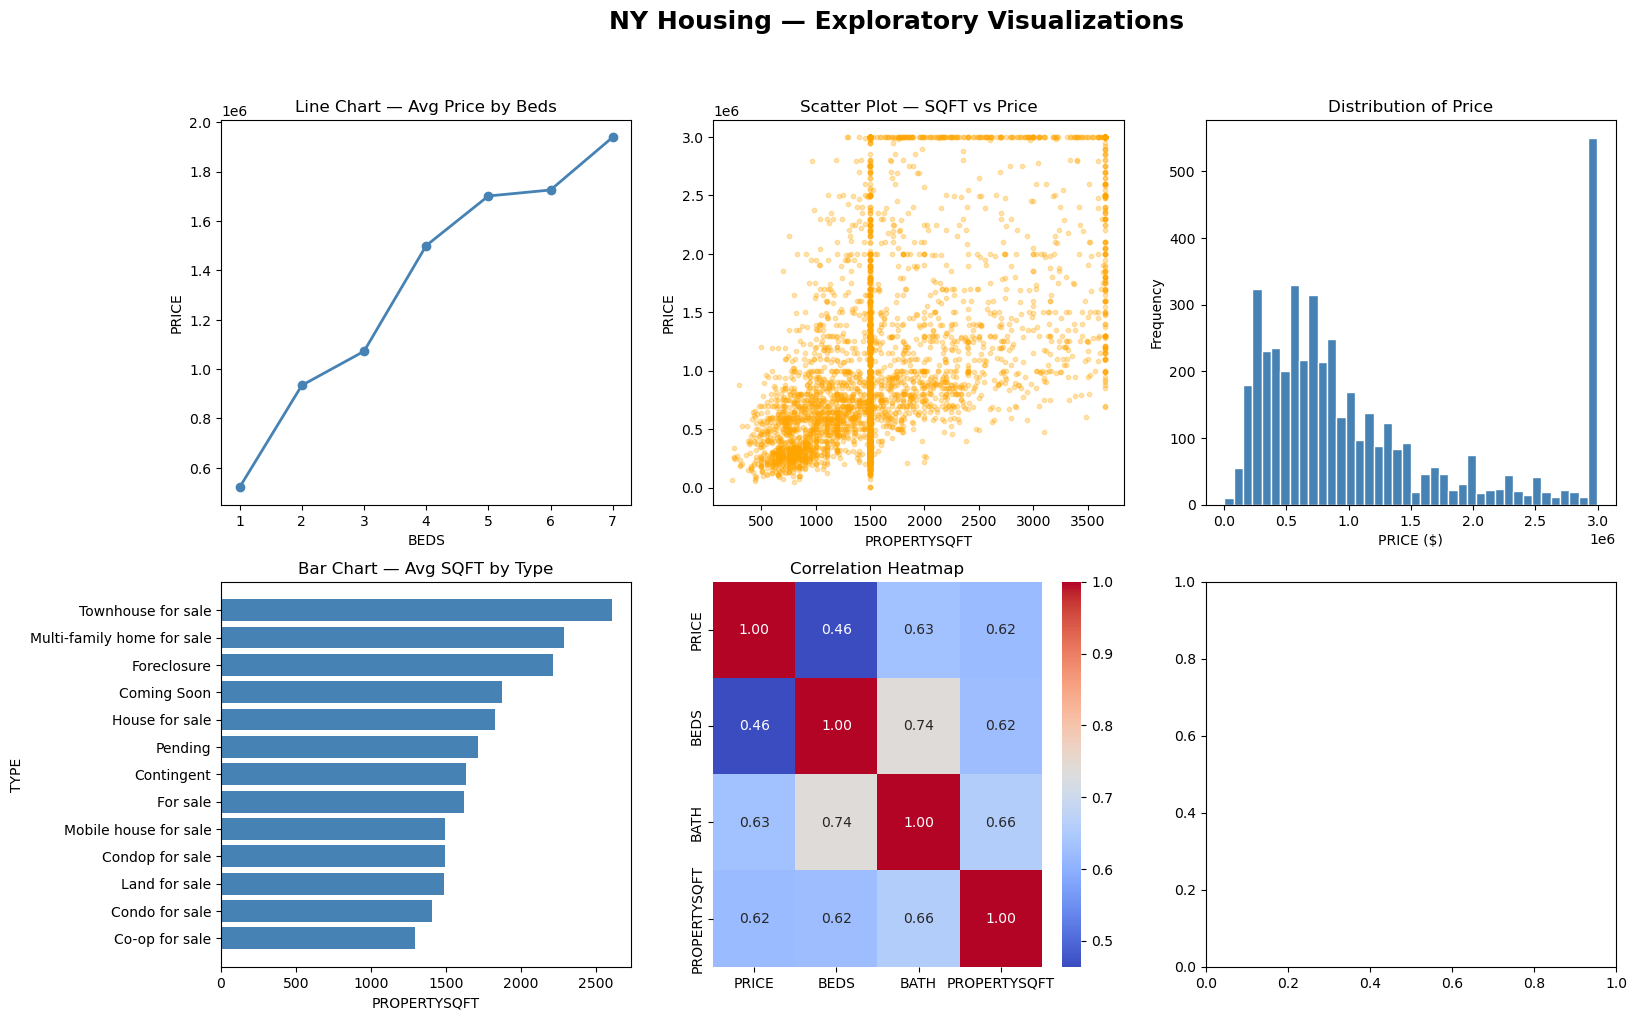

In [20]:
# visuals after cleaning and model training

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('NY Housing — Exploratory Visualizations', fontsize=18, fontweight='bold')

# LINE CHART — Average Price by Beds
avg_price = df.groupby('BEDS')['PRICE'].mean()
axes[0, 0].plot(avg_price.index, avg_price.values, marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_xlabel('BEDS')
axes[0, 0].set_ylabel('PRICE')
axes[0, 0].set_title('Line Chart — Avg Price by Beds')

# SCATTER — SQFT vs Price
axes[0, 1].scatter(df['PROPERTYSQFT'], df['PRICE'], alpha=0.3, s=10, color='orange')
axes[0, 1].set_xlabel('PROPERTYSQFT')
axes[0, 1].set_ylabel('PRICE')
axes[0, 1].set_title('Scatter Plot — SQFT vs Price')

# DISTRIBUTION — Price Histogram
axes[0, 2].hist(df['PRICE'], bins=40, color='steelblue', edgecolor='white')
axes[0, 2].set_xlabel('PRICE ($)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Price')

# BAR CHART — Avg SQFT by Property Type
avg_sqft = df.groupby('TYPE')['PROPERTYSQFT'].mean().sort_values()
axes[1, 0].barh(avg_sqft.index, avg_sqft.values, color='steelblue')
axes[1, 0].set_xlabel('PROPERTYSQFT')
axes[1, 0].set_ylabel('TYPE')
axes[1, 0].set_title('Bar Chart — Avg SQFT by Type')

# HEATMAP — Correlation Matrix
sns.heatmap(df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap')



In [23]:
# Q4 Training models

In [21]:
#Define features (X) and target (y)
X = df[['BEDS', 'BATH', 'PROPERTYSQFT']]
y = df['PRICE']
 
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
 
# Scale features so they are on the same scale (important for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print(f"\nTrain set size : {X_train.shape[0]} rows")
print(f"Test set size  : {X_test.shape[0]} rows")


Train set size : 3669 rows
Test set size  : 918 rows


In [22]:
# linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
# Display coefficients
print(f"Intercept (β0): ${model.intercept_:,.2f}")
for i, coef in enumerate(model.coef_):
    print(f"Coefficient β{i+1}: ${coef:,.2f}")

# Display equation
print(f"PRICE = {model.intercept_:,.2f} + {' + '.join(f'{coef:,.2f} x X{i+1}' for i, coef in enumerate(model.coef_))}")

Intercept (β0): $-61,499.80
Coefficient β1: $-59,375.33
Coefficient β2: $313,385.21
Coefficient β3: $399.77
PRICE = -61,499.80 + -59,375.33 x X1 + 313,385.21 x X2 + 399.77 x X3


In [24]:
# Q5 House Price Prediction

In [25]:

new_property = pd.DataFrame({
    'BEDS': [5],
    'BATH': [5],
    'PROPERTYSQFT': [350]
})

predicted_price = model.predict(new_property)[0]

print(predicted_price)

1348467.5926573067


In [ ]:
# Q6 Performance Evaluation

In [26]:
 # PREDICTION ON TEST SET
y_pred = model.predict(X_test)

# TEST 1 — R² SCORE
r2 = r2_score(y_test, y_pred)
print(f"TEST 1 — R² Score")
print(f"  R² = {r2:.4f}")
print("This evaluation moderate that is; it is not great and also not terrible. It tells us BEDS, BATH and SQFT alone are not enough to fully explain NYC housing prices. Location, floor level, building age, and amenities also matter a lot but aren't in our 3 features" )

# TEST 2 — RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nTEST 2 — RMSE (Root Mean Squared Error)")
print(f"  RMSE = ${rmse:,.2f}")
print("Our model is off by about $618K on average. Given that NYC prices range from $49K to $2.99M after capping, this is a significant error margin. It means if the real price is $1M, the model might predict anywhere between ~$381K and ~$1.6M")

TEST 1 — R² Score
  R² = 0.4520
This evaluation moderate that is; it is not great and also not terrible. It tells us BEDS, BATH and SQFT alone are not enough to fully explain NYC housing prices. Location, floor level, building age, and amenities also matter a lot but aren't in our 3 features

TEST 2 — RMSE (Root Mean Squared Error)
  RMSE = $654,449.06
Our model is off by about $618K on average. Given that NYC prices range from $49K to $2.99M after capping, this is a significant error margin. It means if the real price is $1M, the model might predict anywhere between ~$381K and ~$1.6M
